## Projeto CardioIA - Visão Computacional (Fase 4)
### Parte 1: Pré-processamento e Organização das Imagens
### Parte 2: Classificação de Imagens Médicas com CNN e Transfer Learning

### Importação das Bibliotecas

In [5]:
import os
import shutil
import numpy as np
import zipfile
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16

### Configuração dos Caminhos do Dataset

In [6]:
# Definição dos caminhos locais com base na estrutura de arquivos ZIP
BASE_DIR = r"C:\Users\Fran\Nova pasta\fiap-fase4\dataset_estruturado"

### Carregamento dos Datasets via TensorFlow API

In [7]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("Carregando os subconjuntos de imagens do diretório estruturado...")

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, 'train'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

class_names = train_ds.class_names
print(f"Classes detectadas: {class_names}\n")

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, 'validation'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, 'test'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

Carregando os subconjuntos de imagens do diretório estruturado...
Found 2620 files belonging to 3 classes.
Classes detectadas: ['Cardiomegalia', 'Infiltrado', 'Saudavel']

Found 561 files belonging to 3 classes.
Found 564 files belonging to 3 classes.


In [8]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

print("Performance otimizada com tf.data.AUTOTUNE (Prefetching ativo).")

Performance otimizada com tf.data.AUTOTUNE (Prefetching ativo).


### Inspeção Visual das Imagens Processadas

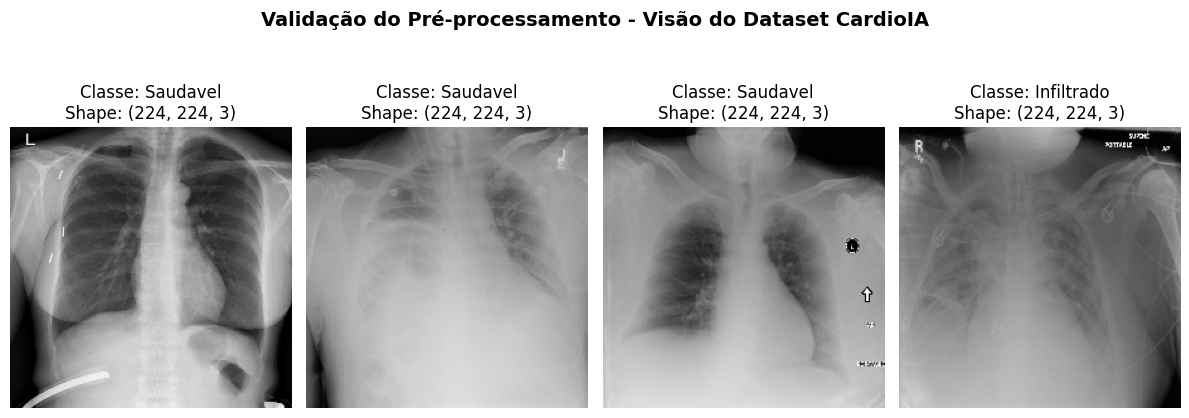

Valor de Pixel Máximo: 255.0 | Mínimo: 0.0


In [9]:
for images_batch, labels_batch in train_ds.take(1):
    plt.figure(figsize=(12, 5))
    for i in range(min(4, len(images_batch))):
        plt.subplot(1, 4, i + 1)
        plt.imshow(images_batch[i].numpy().astype("uint8"))
        label_idx = np.argmax(labels_batch[i])
        plt.title(f"Classe: {class_names[label_idx]}\nShape: {images_batch[i].shape}")
        plt.axis('off')

    plt.suptitle("Validação do Pré-processamento - Visão do Dataset CardioIA", fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()
    print(f"Valor de Pixel Máximo: {images_batch.numpy().max()} | Mínimo: {images_batch.numpy().min()}")

## PARTE 2 - Classificação de Imagens Médicas com CNN
### Abordagem 1: Arquitetura CNN Desenvolvida do Zero

### Cálculo de Pesos de Classe e Definição da CNN do Zero

In [10]:
# Cálculo automático de pesos para combater o desbalanceamento clínico
train_labels = np.concatenate([y for x, y in train_ds], axis=0)
train_labels_indices = np.argmax(train_labels, axis=1)

classes = np.unique(train_labels_indices)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=train_labels_indices)
class_weight_dict = dict(zip(classes, weights))

print(f"Pesos de classe: {class_weight_dict}")

# Camada de Data Augmentation integrada para proteção contra Overfitting
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

# Construção da Rede Convolucional Multiclasse do Zero
model_do_zero = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    layers.Rescaling(1./255), # Normalização dos pixels [0, 1]
    
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax') # Ajustado para 3 neurônios e Softmax
])

model_do_zero.compile(
    optimizer='adam',
    loss='categorical_crossentropy', # Ajustado para multiclasse
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

model_do_zero.summary()

Pesos de classe: {np.int64(0): np.float64(6.374695863746958), np.int64(1): np.float64(1.5707434052757794), np.int64(2): np.float64(0.45320878740702303)}


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
EPOCHS = 10  

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_zero = model_do_zero.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)
print("Treinamento concluído!")

Epoch 1/10


72/82 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.3062 - loss: 1.2708 - precision: 0.5213 - recall: 0.1160

### Avaliação Estatística e Matriz de Confusão

In [ ]:
predictions_zero = model_do_zero.predict(test_ds, verbose=1)
y_pred_zero = np.argmax(predictions_zero, axis=1)

# Extrai o gabarito real do conjunto de teste oculto
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_true_indices = np.argmax(y_true, axis=1)

# Matriz de Confusão
cm_zero = confusion_matrix(y_true_indices, y_pred_zero)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_zero, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão - CNN do Zero (CardioIA)', fontsize=12, weight='bold')
plt.ylabel('Classe Real (Médico)')
plt.xlabel('Classe Predita (IA)')
plt.tight_layout()
plt.show()

print("\n --- RELATÓRIO DE MÉTRICAS ---")
print(classification_report(y_true_indices, y_pred_zero, target_names=class_names))

### Curvas de Loss e Acurácia

In [ ]:
plt.figure(figsize=(12, 4))

# Evolução da Acurácia
plt.subplot(1, 2, 1)
plt.plot(history_zero.history['accuracy'], label='Treino', color='blue', linewidth=2)
plt.plot(history_zero.history['val_accuracy'], label='Validação', color='orange', linewidth=2)
plt.title('Evolução da Acurácia', weight='bold')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)

# Evolução da Perda
plt.subplot(1, 2, 2)
plt.plot(history_zero.history['loss'], label='Treino', color='blue', linewidth=2)
plt.plot(history_zero.history['val_loss'], label='Validação', color='orange', linewidth=2)
plt.title('Evolução da Perda (Loss)', weight='bold')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend()
plt.grid(True)

plt.suptitle("Histórico de Treinamento da Rede do Zero - CardioIA", fontsize=14, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Abordagem 2: Aprendizado por Transferência (Transfer Learning) com VGG16

### Construção do Modelo Customizado VGG16

In [ ]:
# 1. Carregar a VGG16 pré-treinada excluindo o topo original classificatório
base_model = VGG16(
    weights='imagenet',          
    include_top=False,           
    input_shape=(224, 224, 3)    
)

# 2. Congelamento dos pesos do bloco extrator de recursos
base_model.trainable = False

# 3. Construção da Rede com Camada de Entrada e Pré-processador nativo da VGG16
model_vgg = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    # Normalização nativa exigida pela arquitetura VGG16:
    layers.Lambda(tf.keras.applications.vgg16.preprocess_input),
    
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax') # Ajustado para 3 saídas com Softmax
])

model_vgg.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), # LR menor para ajuste fino estável
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

model_vgg.summary()
print("\nModelo VGG16 acoplado e pronto para Transfer Learning!")

### Treinamento da VGG16 Customizada

In [ ]:
EPOCHS_VGG = 10 

history_vgg = model_vgg.fit(
    train_ds,
    epochs=EPOCHS_VGG,
    validation_data=val_ds,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)


### Avaliação Estatística e Matriz de Confusão (VGG16)

In [ ]:
print("Computando predições para o conjunto de teste com a VGG16...")
predictions_vgg = model_vgg.predict(test_ds, verbose=1)
y_pred_vgg = np.argmax(predictions_vgg, axis=1)

# Matriz de Confusão
cm_vgg = confusion_matrix(y_true_indices, y_pred_vgg)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_vgg, annot=True, fmt='d', cmap='Oranges', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão - Transfer Learning VGG16', fontsize=12, weight='bold')
plt.ylabel('Classe Real (Médico)')
plt.xlabel('Classe Predita (IA)')
plt.tight_layout()
plt.show()

print("\n --- RELATÓRIO DE MÉTRICAS (VGG16) ---")
print(classification_report(y_true_indices, y_pred_vgg, target_names=class_names))